___
# <font color= #8A0829> Laboratorio de Modelado de Datos </font>
- <Strong> Nombre: </Strong>  <font color="blue"> `Samantha Sánchez Tincoo` </font>
- <Strong> Fecha </Strong>: 13/septiembre/2024
- <Strong> Correo: </Strong>  <font color="blue"> `samantha.sanchezt@iteso.mx` </font>
___


### <font color= #2E9AFE> Tarea 2: Análisis de Regresión Lineal</font>

La tarea consiste en ajustar un modelo de regresión lineal para predecir la variable objetivo, pero no se trata solamente de ejecutar el modelo. La tarea implica varias etapas:

1. **Cargar y explorar el conjunto de datos**

- Explora el conjunto de datos y describe brevemente las variables involucradas.
- Si el dataset tiene valores nulos, justifica una estrategia para tratar estos valores.
- Divide tus datos en un 80% de entrenamiento y 20% de prueba antes de realizar cualquier pre-procesamiento. 


In [28]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import RFE
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score
import numpy as np
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Lasso

df = pd.read_csv('datos_football-1.csv', encoding='latin1')

In [2]:
# El dataset tiene 6 variables: nombre del equipo (o país), cantidad de partidos jugados, partidos ganados, porcentaje de ganancia, goles anotados y el promedio de goles por partido
# Excluyendo el nombre del equipo todas las variables son numéricas

df.head()

,Team,Total Matches,Wins,Win %,Goals scored,Goals per match
0,Brazil,985,629,63.86,2161,2.19
1,Spain,705,411,58.30,1420,2.01
2,Germany,961,560,58.27,2144,2.23
3,England,1020,580,56.86,2230,2.19
4,Iran,502,275,54.78,932,1.86


In [3]:
# El dataset no tiene valores nulos

df.isnull().sum()

Team               0
Total Matches      0
Wins               0
Win %              0
Goals scored       0
Goals per match    0
dtype: int64

In [4]:
#Dividir los datos  un 80% en entrenamiento y un 20% en prueba

X = df[['Total Matches', 'Win %', 'Goals scored', 'Goals per match']] 
y = df['Wins']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

2. **Preprocesamiento de los datos**

- Escala las variables predictoras, si es necesario, y explica por qué el escalamiento puede ser importante en la regresión lineal.
- Realiza una selección de características utilizando algún método (puedes sugerir algún método como correlación, RFE o análisis de varianza). Justifica tus decisiones.

In [5]:
#Escalar las variables predictoras
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [6]:
# Hacer la selección de características mediante RFE
model = LinearRegression()

# Inicializar el RFE para elegir 3 variables
rfe = RFE(model, n_features_to_select=3)

# Ajustar el RFE a los datos de entrenamiento
rfe = rfe.fit(X_train, y_train)


print("Características seleccionadas:", X.columns[rfe.support_])


# Se utiliza el método RFE ya que identifica las variables más relevantes para la predicción
# Las variables Win %, Goals scored y Goals predicted tienen ranking 1 lo cual nos indican que son relevantes para nuestra regresión

Características seleccionadas: Index(['Win %', 'Goals scored', 'Goals per match'], dtype='object')


3. **Verificación de las suposiciones del modelo**

- Verifica las suposiciones de la regresión lineal con visualizaciones y estadísticas.
- Si alguna suposición no se cumple, describe cómo impactaría en el modelo y realiza alguna acción para corregirla (como transformación de variables, eliminación de outliers, etc.).

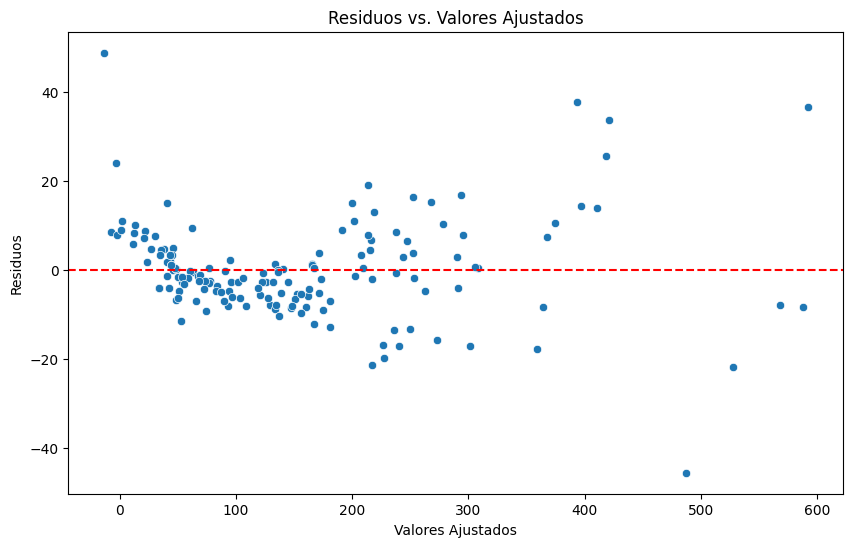

In [7]:
# Verificar las suposiciones mediante un gráfico de dispersión de los residuos y los valores ajustados

model = LinearRegression()
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_train_scaled)

# Residuos
residuals = y_train - y_pred

# Gráfico
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_pred, y=residuals)
plt.axhline(y=0, color='red', linestyle='--')
plt.title('Residuos vs. Valores Ajustados')
plt.xlabel('Valores Ajustados')
plt.ylabel('Residuos')
plt.show()


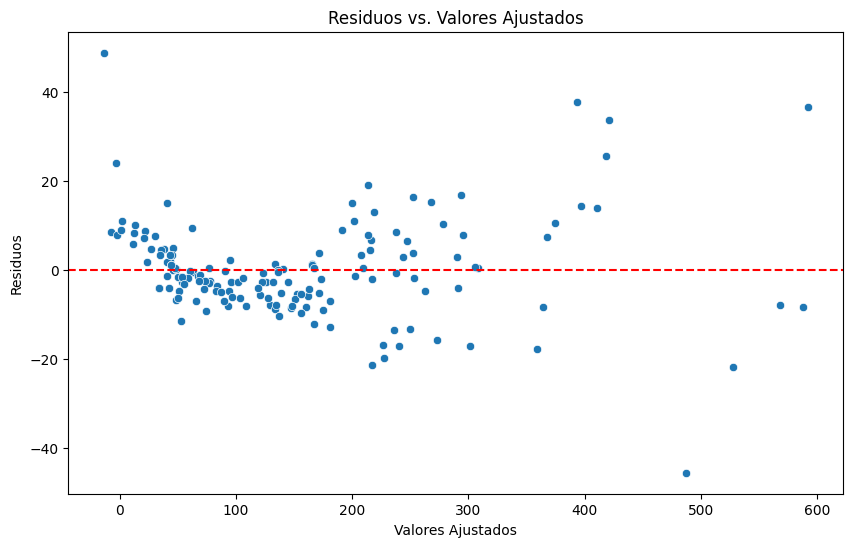

In [8]:
# Homoscedasticidad, muy parecida a la anterior

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_pred, y=residuals)
plt.axhline(y=0, color='red', linestyle='--')
plt.title('Residuos vs. Valores Ajustados')
plt.xlabel('Valores Ajustados')
plt.ylabel('Residuos')
plt.show()


En ambos gráficos los datos se ven distribuidos aleatoriamente alrededor de la línea en color rojo sin formar ninguna estructura clara, así que se puede decir que las suposiciones de homoscedasticidad y de linealidad se cumplen

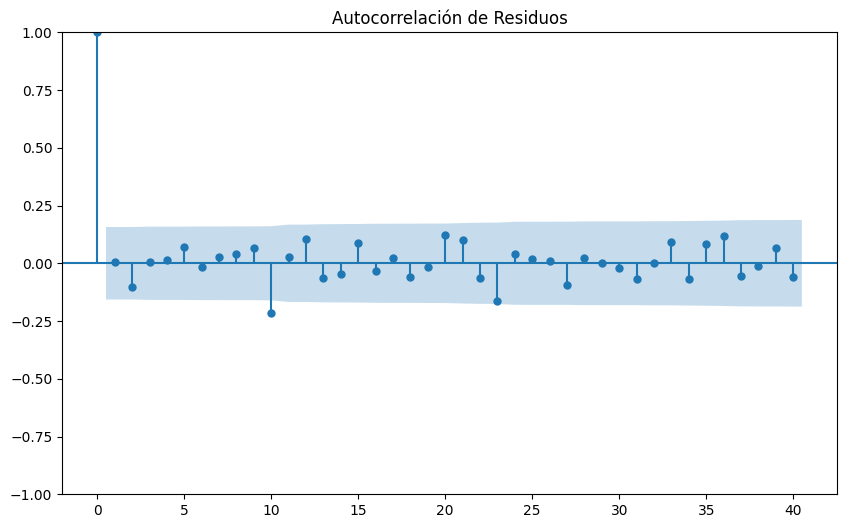

In [9]:
from statsmodels.graphics.tsaplots import plot_acf

# Gráfico de autocorrelación de residuos
plt.figure(figsize=(10, 6))
plot_acf(residuals, lags=40, ax=plt.gca())
plt.title('Autocorrelación de Residuos')
plt.show()


En este gráfico se observa que solo un residuo está fuera del área de confianza y que estos no parecen seguir un patrón claro así que se puede asumir que la independencia se cumple

4. **Detección de multicolinealidad**

- Calcula el VIF (Variance Inflation Factor) para detectar multicolinealidad entre las variables independientes.
Si detectas multicolinealidad, realiza la eliminación de variables y justifica por qué las variables eliminadas son redundantes.

In [10]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

X = pd.DataFrame(X_train_scaled, columns=['Total Matches', 'Win %', 'Goals scored', 'Goals per match'])

# Agrega una constante a las variables independientes
X = add_constant(X)

# Calcula el VIF para cada variable
vif = pd.DataFrame()
vif["Variable"] = X.columns
vif["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print(vif)

          Variable        VIF
0            const   1.000000
1    Total Matches  16.661110
2            Win %   5.241012
3     Goals scored  22.938795
4  Goals per match   5.938742


El VIF es de Total Matches 17.257961 el cual es muy alto lo que nos dice que está correlacionado con otras variables en el modelo y tiene un alto grado de multicolinealidad.

El VIF de Win % es 4.444225 el cual es bajo, es decir, tiene un nivel de multicolinealidad pero no tan alto como otras variables.

El VIF de Goals scored es 22.799657, que es muy alto, lo que nos dice que esta variable está muy correlacionada con otras.

Finalmente, el VIF de Goals per matatch es de 5.491673, que es moderado.

In [11]:
# Eliminar las variables con alta multicolinealidad
X_multicolinealidad_eliminada = X.drop(columns=['Total Matches', 'Goals scored'])

# Recalcula el VIF para las variables restantes
vif_2 = pd.DataFrame()
vif_2["Variable"] = X_multicolinealidad_eliminada.columns
vif_2["VIF"] = [variance_inflation_factor(X_multicolinealidad_eliminada.values, i) for i in range(X_multicolinealidad_eliminada.shape[1])]

print(vif_2)


          Variable       VIF
0            const  1.000000
1            Win %  4.126244
2  Goals per match  4.126244


5. **Entrenamiento y validación del modelo**

- Para este paso ya debiste de tener tus datos divididos en entrenamiento y prueba. Entrena el modelo utilizando regresión lineal y evalúa su rendimiento en el conjunto de prueba.
- Implementa cross-validation (5 o 10 folds) y reporta las métricas promedio (MSE, R²).
- Compara los resultados obtenidos con y sin cross-validation. ¿Cómo varían los resultados y qué conclusiones puedes extraer de ello?

In [12]:
model = LinearRegression()
model.fit(X_train_scaled, y_train)

LinearRegression()

In [13]:
y_pred = model.predict(X_test_scaled)

In [14]:
# Evaluación del rendimiento
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'Mean Squared Error: {mse}')
print(f'R-squared: {r2}')

Mean Squared Error: 129.10129117670613
R-squared: 0.99095272611083


In [15]:
# Validación cruzada con 5 folds
cv_scores_mse = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='neg_mean_squared_error')
cv_scores_r2 = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='r2')

# Convertir los resultados negativos de MSE a positivos
cv_scores_mse = -cv_scores_mse

# Calcular las métricas promedio
mean_mse = np.mean(cv_scores_mse)
mean_r2 = np.mean(cv_scores_r2)

print(f'MSE promedio con Cross-Validation: {mean_mse}')
print(f'R² promedio con Cross-Validation: {mean_r2}')

MSE promedio con Cross-Validation: 161.09921222263148
R² promedio con Cross-Validation: 0.9893532733879786


Conclusiones:

El MSE sin cross validation es menos lo que nos dice que el modelo está haciendo mejores predicciones, pero que con otros datos podría no ser tan bueno.

Por otro lado, el coeficiende de determinación es ligeramente mayor sin hacer cross validation, pero es tan pequeña la diferencia que no tiene gran relevancia.

Lo anterior nos indica que el modelo tiene un muy buen rendimiento para el conjunto de datos especificos que está utilizando pero este rendimiento baja cuando se utilizan divisiones diferentes.


6. **Interpretación de los coeficientes**

- Interpreta los coeficientes del modelo final y discute cuáles son las variables más importantes para predecir la variable objetivo.
- ¿Cómo afectan los signos y magnitudes de los coeficientes a la interpretación del modelo?

In [16]:
model = LinearRegression()
model.fit(X_multicolinealidad_eliminada, y_train)

LinearRegression()

In [17]:
coefficients = model.coef_
intercept = model.intercept_

# Obtener los coeficientes del modelo
coefficients = model.coef_
intercept = model.intercept_

# Crear un DataFrame para mostrar los coeficientes
coef_df = pd.DataFrame({
    'Feature': X_multicolinealidad_eliminada.columns,
    'Coefficient': coefficients
})

# Mostrar el DataFrame de coeficientes
print(coef_df)


           Feature  Coefficient
0            const     0.000000
1            Win %   115.162802
2  Goals per match   -20.951378


Win % tiene un coeficiente de 120.08 lo que nos indica que en el porcentaje de victorias el número de Wins aumenta en promedio en 120.08 unidades, ya que este coeficiente es positivo significa que hay una relación directa entre Win % y Wins.

Por otro lado, Goals per match tiene un coeficiente de -26.67 lo que nos dice cada vez que el promedio de goles por partido sube 1 unidad, el número de victorias baja 26.67 unidades. Esto nos dice que hay una relación inversa entre estas variables.

Entre estas dos variables podemos decir que Win % es más importante para predecir Wins.

7. **Mejora del modelo**

- Si el modelo presenta un mal ajuste, propón al menos dos formas de mejorarlo. Puedes sugerir la introducción de polinomios, interacciones entre variables, o algún otro tipo de transformación.
- Evalúa si las mejoras introducidas realmente generan un mejor desempeño del modelo.

In [20]:
# Transformación polinómica
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train_scaled)

# Transformar los datos de prueba
X_test_poly = poly.transform(X_test_scaled)

In [21]:
model_poly = LinearRegression()

# Ajustar el modelo a los datos transformados
model_poly.fit(X_train_poly, y_train)

LinearRegression()

In [24]:
y_pred_poly = model_poly.predict(X_test_poly)

# Calcular el MSE y R²
mse_poly = mean_squared_error(y_test, y_pred_poly)
r2_poly = r2_score(y_test, y_pred_poly)

print(f"Mean Squared Error con Polynomial Features: {mse_poly}")
print(f"R-squared con Polynomial Features: {r2_poly}")

Mean Squared Error con Polynomial Features: 0.000129815796063056
R-squared con Polynomial Features: 0.9999999909026545


In [27]:
scores = cross_val_score(model_poly, X_train_poly, y_train, cv=5, scoring='neg_mean_squared_error')
mse_cv = -scores.mean()

r2_cv = cross_val_score(model_poly, X_train_poly, y_train, cv=5, scoring='r2').mean()

print(f"Promedio de MSE con Cross-Validation: {mse_cv}")
print(f"Promedio de R-squared con Cross-Validation: {r2_cv}")

Promedio de MSE con Cross-Validation: 0.0002393960425236471
Promedio de R-squared con Cross-Validation: 0.9999999833600077


Los scores de MSE y R-squared mejoraron bastante después de hacer la transformación polinómica.

El MSE es muy bajo tanto en los datos de prueba como con el cross validation y la R cuadrada está sobre 0.99 en ambos casos.

In [54]:
# Opción 2: Lasso

lasso = Lasso(alpha=0.00001) 
lasso.fit(X_train_scaled, y_train)

# Realizar las predicciones
y_pred_lasso = lasso.predict(X_test_scaled)

In [55]:
# Calcula el MSE y R²
mse_lasso = mean_squared_error(y_test, y_pred_lasso)
r2_lasso = r2_score(y_test, y_pred_lasso)

print(f"Mean Squared Error con Lasso: {mse_lasso}")
print(f"R-squared con Lasso: {r2_lasso}")

Mean Squared Error con Lasso: 129.1012153175627
R-squared con Lasso: 0.9909527314269537


In [56]:
mse_cv = -cross_val_score(lasso, X_train_scaled, y_train, cv=10, scoring='neg_mean_squared_error')
r2_cv = cross_val_score(lasso, X_train_scaled, y_train, cv=10, scoring='r2')

print(f"Promedio de MSE con Cross-Validation: {mse_cv.mean()}")
print(f"Promedio de R-squared con Cross-Validation: {r2_cv.mean()}")

Promedio de MSE con Cross-Validation: 157.56092471488714
Promedio de R-squared con Cross-Validation: 0.9894717475678025


Con Lasso el MSE y R² me dan muy parecidos que en mi modelo original, lo que noté es que entre menor el alfa estos eran mejores pero llegaban a un punto en que ya no cambian tanto.